<a href="https://colab.research.google.com/github/LAXMI15PRIYA/customer-churn-analysis/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
#Importing the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [55]:
#load the dataset
customers = pd.read_csv("Customers.csv")
churn = pd.read_csv("Churn.csv")
subscriptions = pd.read_csv("Subscriptions.csv")
transactions = pd.read_csv("Transactions.csv")

customers.head(10)
churn.head(10)
subscriptions.head(10)
transactions.head(10)

,TransactionID,CustomerID,TransactionDate,Amount,TransactionType
0,1,15,01-01-2024,32,Purchase
1,2,22,02-01-2024,52,Refund
2,3,43,03-01-2024,165,Purchase
3,4,87,04-01-2024,134,Purchase
4,5,34,05-01-2024,158,Purchase
5,6,56,06-01-2024,170,Refund
6,7,23,07-01-2024,196,Purchase
7,8,11,08-01-2024,195,Purchase
8,9,76,09-01-2024,143,Purchase
9,10,45,10-01-2024,69,Refund


In [8]:
customers.head(10)

,CustomerID,FirstName,LastName,Email,PhoneNumber,JoinDate,Status,Region
0,1,John,Doe,john.doe@example.com,123-456-7890,10-01-2022,Active,North America
1,2,Jane,Smith,jane.smith@example.com,098-765-4321,15-12-2021,Inactive,Europe
2,3,Alice,Johnson,alice.j@example.com,567-890-1234,20-03-2020,Active,Asia
3,4,Bob,Brown,bob.brown@example.com,234-567-8901,25-06-2019,Inactive,North America
4,5,Charlie,Davis,charlie.d@example.com,345-678-9012,14-07-2021,Active,Europe
5,6,Diana,Clark,diana.c@example.com,456-789-0123,30-08-2018,Active,Asia
6,7,Eva,Harris,eva.h@example.com,567-890-1234,22-12-2020,Inactive,North America
7,8,Frank,Garcia,frank.g@example.com,678-901-2345,11-03-2019,Active,Europe
8,9,Grace,Miller,grace.m@example.com,789-012-3456,18-02-2022,Inactive,Asia
9,10,Hank,Wilson,hank.w@example.com,890-123-4567,27-05-2020,Active,North America


In [12]:
customer_names=customers[["FirstName","LastName"]]
customer_names.head(20)

,FirstName,LastName
0,John,Doe
1,Jane,Smith
2,Alice,Johnson
3,Bob,Brown
4,Charlie,Davis
5,Diana,Clark
6,Eva,Harris
7,Frank,Garcia
8,Grace,Miller
9,Hank,Wilson


In [16]:
#which customers are from north America
lohit=customers[customers["Region"]=="North America"]
lohit.head(20)

,CustomerID,FirstName,LastName,Email,PhoneNumber,JoinDate,Status,Region
0,1,John,Doe,john.doe@example.com,123-456-7890,10-01-2022,Active,North America
3,4,Bob,Brown,bob.brown@example.com,234-567-8901,25-06-2019,Inactive,North America
6,7,Eva,Harris,eva.h@example.com,567-890-1234,22-12-2020,Inactive,North America
9,10,Hank,Wilson,hank.w@example.com,890-123-4567,27-05-2020,Active,North America
12,13,Kelly,Lewis,kelly.l@example.com,123-456-7890,15-04-2018,Active,North America
15,16,Noah,Allen,noah.a@example.com,456-789-0123,19-06-2021,Inactive,North America
18,19,Quinn,Scott,quinn.s@example.com,789-012-3456,05-01-2018,Active,North America
21,22,Tina,Perez,tina.p@example.com,012-345-6789,09-08-2020,Inactive,North America
24,25,Wendy,Cook,wendy.c@example.com,345-678-9012,21-07-2019,Active,North America
27,28,Zane,Evans,zane.e@example.com,678-901-2345,13-12-2019,Inactive,North America


In [25]:
#Identify the number of rows
lohit.shape[0]

103

In [26]:
#Identify the number of columns
lohit.shape[1]


8

<bound method DataFrame.value_counts of      CustomerID FirstName LastName                      Email   PhoneNumber  \
0             1      John      Doe       john.doe@example.com  123-456-7890   
3             4       Bob    Brown      bob.brown@example.com  234-567-8901   
6             7       Eva   Harris          eva.h@example.com  567-890-1234   
9            10      Hank   Wilson         hank.w@example.com  890-123-4567   
12           13     Kelly    Lewis        kelly.l@example.com  123-456-7890   
..          ...       ...      ...                        ...           ...   
287         288    Rachel   Harris  rachel.harris@example.com  678-901-2345   
290         291     Lucas   Taylor   lucas.taylor@example.com  901-234-5678   
293         294    Sophia   Morris  sophia.morris@example.com  234-567-8901   
296         297      Liam   Wilson    liam.wilson@example.com  567-890-1234   
299         300     Lucas      Lee      lucas.lee@example.com  890-123-4567   

       Join

In [42]:
neel=customers["Region"].value_counts()
print(neel)

Region
North America    103
Europe           100
Asia              96
Name: count, dtype: int64


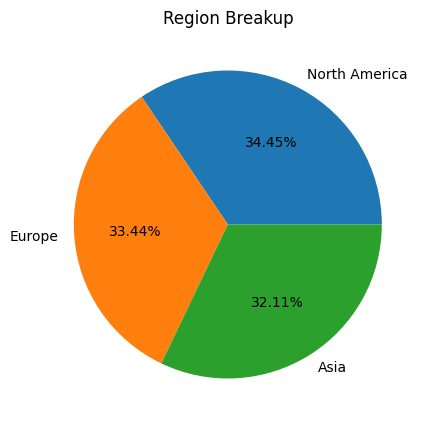

In [46]:
plt.figure(figsize=(9,5))
plt.pie(neel,labels=neel.index,autopct="%1.2f%%")
plt.title("Region Breakup")
plt.show()

,CustomerID,FirstName,LastName,Email,PhoneNumber,JoinDate,Status,Region
0,1,John,Doe,john.doe@example.com,123-456-7890,10-01-2022,Active,North America
1,2,Jane,Smith,jane.smith@example.com,098-765-4321,15-12-2021,Inactive,Europe
2,3,Alice,Johnson,alice.j@example.com,567-890-1234,20-03-2020,Active,Asia
3,4,Bob,Brown,bob.brown@example.com,234-567-8901,25-06-2019,Inactive,North America
4,5,Charlie,Davis,charlie.d@example.com,345-678-9012,14-07-2021,Active,Europe
5,6,Diana,Clark,diana.c@example.com,456-789-0123,30-08-2018,Active,Asia
6,7,Eva,Harris,eva.h@example.com,567-890-1234,22-12-2020,Inactive,North America
7,8,Frank,Garcia,frank.g@example.com,678-901-2345,11-03-2019,Active,Europe
8,9,Grace,Miller,grace.m@example.com,789-012-3456,18-02-2022,Inactive,Asia
9,10,Hank,Wilson,hank.w@example.com,890-123-4567,27-05-2020,Active,North America


In [31]:
#Total count of customers
customers.shape[0]

300

In [32]:
customers.head(20)

,CustomerID,FirstName,LastName,Email,PhoneNumber,JoinDate,Status,Region
0,1,John,Doe,john.doe@example.com,123-456-7890,10-01-2022,Active,North America
1,2,Jane,Smith,jane.smith@example.com,098-765-4321,15-12-2021,Inactive,Europe
2,3,Alice,Johnson,alice.j@example.com,567-890-1234,20-03-2020,Active,Asia
3,4,Bob,Brown,bob.brown@example.com,234-567-8901,25-06-2019,Inactive,North America
4,5,Charlie,Davis,charlie.d@example.com,345-678-9012,14-07-2021,Active,Europe
5,6,Diana,Clark,diana.c@example.com,456-789-0123,30-08-2018,Active,Asia
6,7,Eva,Harris,eva.h@example.com,567-890-1234,22-12-2020,Inactive,North America
7,8,Frank,Garcia,frank.g@example.com,678-901-2345,11-03-2019,Active,Europe
8,9,Grace,Miller,grace.m@example.com,789-012-3456,18-02-2022,Inactive,Asia
9,10,Hank,Wilson,hank.w@example.com,890-123-4567,27-05-2020,Active,North America


In [37]:
#How many active vs inactive customers are there
#How many active customers are there from Europe
count=customers[(customers['Status']=="Active")& (customers["Region"]=="Europe")]
count.shape[0]

47

In [49]:
#Show the subscriptions and the customers who take the  Annual Plan
plan=subscriptions[subscriptions["PlanType"]=="Annual"]
plan.shape[0]

200

/tmp/ipykernel_756/2479995742.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a=sns.countplot(x="PlanType",data=subscriptions,palette="Set1")


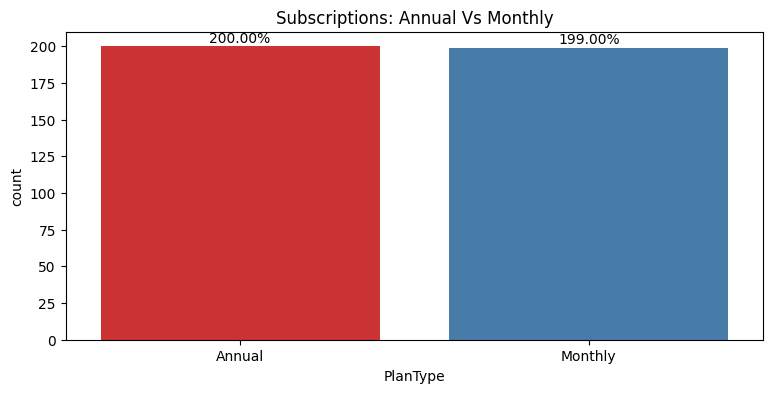

In [14]:
#Bar chart for Annual vs Monthly Subscriptions
plt.figure(figsize=(9,4))
a=sns.countplot(x="PlanType",data=subscriptions,palette="Set1")
for container in a.containers:
  a.bar_label(container,fmt="%1.2f%%",padding=1)
plt.title("Subscriptions: Annual Vs Monthly")
plt.show()

In [47]:
#Visualize with barchart with annaual & monthly subscription
plt.figure(figsize=(9,6))
sns.countplot(x=)

,SubscriptionID,CustomerID,StartDate,EndDate,PlanType
0,1,1,10-01-2022,09-01-2023,Annual
1,2,2,15-12-2021,14-12-2022,Monthly
2,3,3,20-03-2020,19-03-2021,Annual
3,4,4,25-06-2019,24-06-2020,Annual
4,5,5,14-07-2021,13-07-2022,Monthly
5,6,6,30-08-2018,29-08-2019,Annual
6,7,7,22-12-2020,21-12-2021,Monthly
7,8,8,11-03-2019,10-03-2020,Annual
8,9,9,18-02-2022,17-02-2023,Monthly
9,10,10,27-05-2020,26-05-2021,Annual


In [16]:

transactions.head(10)

,TransactionID,CustomerID,TransactionDate,Amount,TransactionType
0,1,15,01-01-2024,32,Purchase
1,2,22,02-01-2024,52,Refund
2,3,43,03-01-2024,165,Purchase
3,4,87,04-01-2024,134,Purchase
4,5,34,05-01-2024,158,Purchase
5,6,56,06-01-2024,170,Refund
6,7,23,07-01-2024,196,Purchase
7,8,11,08-01-2024,195,Purchase
8,9,76,09-01-2024,143,Purchase
9,10,45,10-01-2024,69,Refund


In [24]:
#How amny transaction above>$100
gfg=transactions[(transactions["Amount"]>100)]
gfg.shape[0]

125

In [18]:
#Create a pie chart to visualize above 100&below 100
transactions.head(10)

,TransactionID,CustomerID,TransactionDate,Amount,TransactionType
0,1,15,01-01-2024,32,Purchase
1,2,22,02-01-2024,52,Refund
2,3,43,03-01-2024,165,Purchase
3,4,87,04-01-2024,134,Purchase
4,5,34,05-01-2024,158,Purchase
5,6,56,06-01-2024,170,Refund
6,7,23,07-01-2024,196,Purchase
7,8,11,08-01-2024,195,Purchase
8,9,76,09-01-2024,143,Purchase
9,10,45,10-01-2024,69,Refund


In [19]:
transactions.head(10)

,TransactionID,CustomerID,TransactionDate,Amount,TransactionType
0,1,15,01-01-2024,32,Purchase
1,2,22,02-01-2024,52,Refund
2,3,43,03-01-2024,165,Purchase
3,4,87,04-01-2024,134,Purchase
4,5,34,05-01-2024,158,Purchase
5,6,56,06-01-2024,170,Refund
6,7,23,07-01-2024,196,Purchase
7,8,11,08-01-2024,195,Purchase
8,9,76,09-01-2024,143,Purchase
9,10,45,10-01-2024,69,Refund


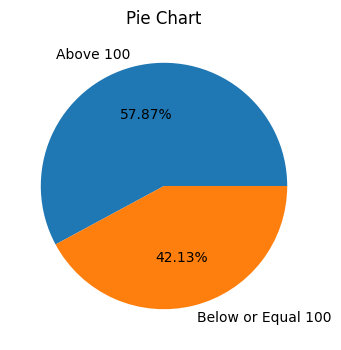

In [28]:
#Create a piechart to visualize Transaction Above 100&below 100

#Create two Categories:"Above 100","Below/Equal100"

transactions["Amount_Category"]=transactions["Amount"].apply(lambda i:"Above 100" if i>100 else "Below or Equal 100")
transactions.head(20)
category_count=transactions["Amount_Category"].value_counts()
plt.figure(figsize=(6,4))
plt.pie(category_count,labels=category_count.index,autopct="%1.2f%%")
plt.title("Pie Chart")
plt.show()

/tmp/ipykernel_756/1864131897.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a=sns.countplot(x="Amount_Category",data=transactions,palette="Set1")


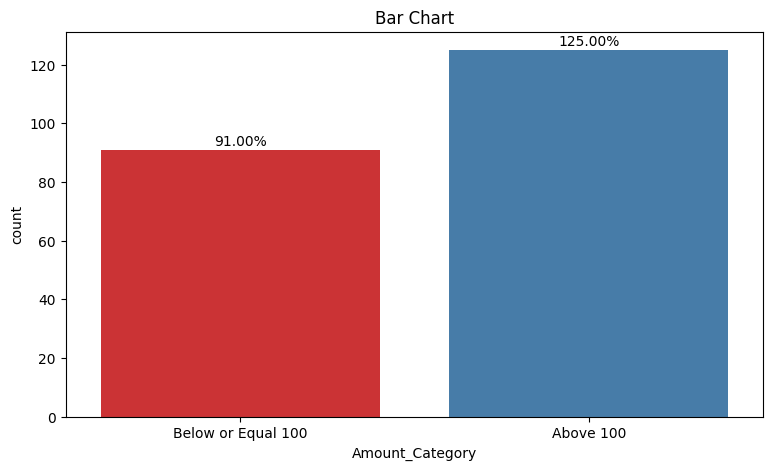

In [29]:
plt.figure(figsize=(9,5))
a=sns.countplot(x="Amount_Category",data=transactions,palette="Set1")
for container in a.containers:
  a.bar_label(container,fmt="%1.2f%%",padding=1)
plt.title("Bar Chart")
plt.show()


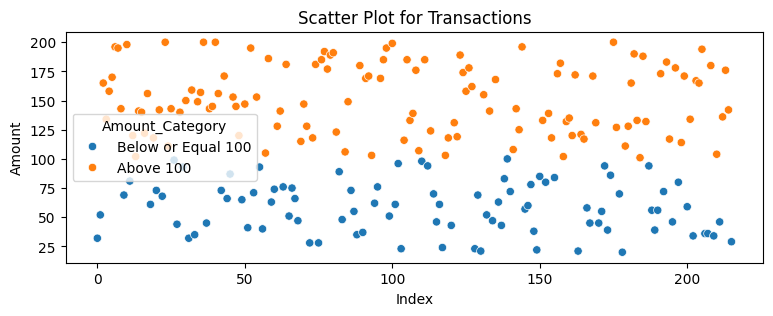

In [32]:
#Scatter plot for who made more purchases
plt.figure(figsize=(9,3))
sns.scatterplot(x=transactions.index,y="Amount",hue="Amount_Category",data=transactions)
plt.title("Scatter Plot for Transactions")
plt.xlabel("Index")
plt.show()


In [35]:
#Show the comaprison between churned count and non churned count
churn.head(10)

,ChurnID,CustomerID,ChurnDate,Reason
0,1,22,02-01-2024,Poor Customer Service
1,2,56,06-06-2024,High Prices
2,3,45,10-10-2024,Product Quality Issues
3,4,54,12-12-2024,Lack of Product Features
4,5,82,14-02-2024,Competitor Offerings
5,6,67,15-01-2024,Inconvenience
6,7,17,21-01-2024,Lack of Engagement
7,8,33,18-01-2024,Unmet Expectations
8,9,91,20-01-2024,Price Increases
9,10,23,23-01-2024,Personal Circumstances


In [40]:
#Show a comaprison between churned count & non-churned count
total_customers=customers.shape[0]
total_churned=churn.shape[0]
total_not_churned=total_customers-total_churned
print("Total Churned Customers:",total_churned)
print("Total_not_churned",total_not_churned)

Total Churned Customers: 100
Total_not_churned 200


In [41]:
#Create a DataFrame to represent churned vs not churned Data
churn_status=pd.DataFrame({"Status":["Churned","Not Churned"],"Count":[total_churned,total_not_churned]})
churn_status.head(20)

,Status,Count
0,Churned,100
1,Not Churned,200


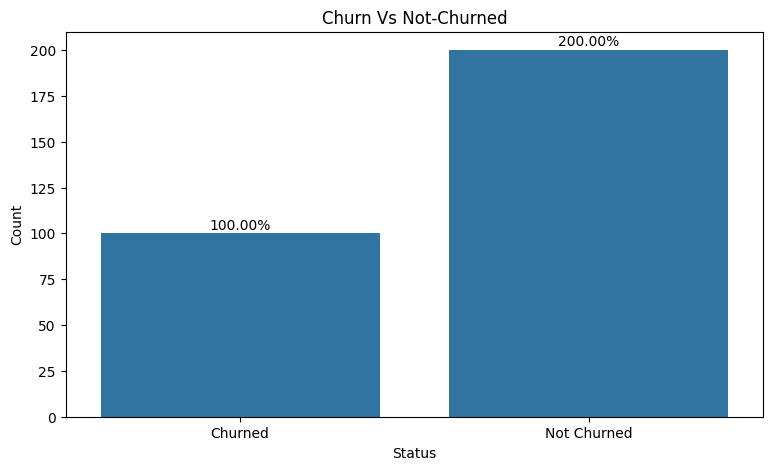

In [49]:
plt.figure(figsize=(9,5))
a = sns.barplot(x="Status", y="Count", data=churn_status)

for container in a.containers:
    a.bar_label(container, fmt="%1.2f%%", padding=1)

plt.title("Churn Vs Not-Churned")
plt.show()

In [57]:
#How many Active Customers who have Annual Subscription
samriddhi=pd.merge(customers,subscriptions,on="CustomerID")
samriddhi.head(10)

,CustomerID,FirstName,LastName,Email,PhoneNumber,JoinDate,Status,Region,SubscriptionID,StartDate,EndDate,PlanType
0,1,John,Doe,john.doe@example.com,123-456-7890,10-01-2022,Active,North America,1,10-01-2022,09-01-2023,Annual
1,1,John,Doe,john.doe@example.com,123-456-7890,10-01-2022,Active,North America,44,10-01-2023,09-01-2024,Monthly
2,1,John,Doe,john.doe@example.com,123-456-7890,10-01-2022,Active,North America,101,01-07-2023,30-06-2024,Monthly
3,2,Jane,Smith,jane.smith@example.com,098-765-4321,15-12-2021,Inactive,Europe,2,15-12-2021,14-12-2022,Monthly
4,2,Jane,Smith,jane.smith@example.com,098-765-4321,15-12-2021,Inactive,Europe,45,15-12-2022,14-12-2023,Annual
5,2,Jane,Smith,jane.smith@example.com,098-765-4321,15-12-2021,Inactive,Europe,102,15-05-2022,14-05-2023,Annual
6,3,Alice,Johnson,alice.j@example.com,567-890-1234,20-03-2020,Active,Asia,3,20-03-2020,19-03-2021,Annual
7,3,Alice,Johnson,alice.j@example.com,567-890-1234,20-03-2020,Active,Asia,46,20-03-2021,19-03-2022,Monthly
8,3,Alice,Johnson,alice.j@example.com,567-890-1234,20-03-2020,Active,Asia,103,01-08-2021,31-07-2022,Monthly
9,4,Bob,Brown,bob.brown@example.com,234-567-8901,25-06-2019,Inactive,North America,4,25-06-2019,24-06-2020,Annual


In [59]:
annual_active_count=samriddhi[(samriddhi["Status"]=="Active") & (samriddhi['PlanType']=="Annual")]
annual_active_count.shape[0]

82

In [62]:
#Find customers and their total spend
total_spend_per_customer=transactions.groupby("CustomerID")["Amount"].sum().reset_index()
total_spend_per_customer.head(20)

,CustomerID,Amount
0,11,195
1,15,32
2,17,73
3,19,140
4,21,32
5,22,52
6,23,196
7,25,122
8,26,110
9,28,153


In [60]:
transactions.head(10)

,TransactionID,CustomerID,TransactionDate,Amount,TransactionType
0,1,15,01-01-2024,32,Purchase
1,2,22,02-01-2024,52,Refund
2,3,43,03-01-2024,165,Purchase
3,4,87,04-01-2024,134,Purchase
4,5,34,05-01-2024,158,Purchase
5,6,56,06-01-2024,170,Refund
6,7,23,07-01-2024,196,Purchase
7,8,11,08-01-2024,195,Purchase
8,9,76,09-01-2024,143,Purchase
9,10,45,10-01-2024,69,Refund
